In [21]:
import pandas as pd
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("C:\\Users\\katta\\Downloads\\data (1).csv")
df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


In [23]:
cluster_features = [
    "Income",
    "Rent",
    "Loan_Repayment",
    "Groceries",
    "Transport",
    
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous"
]

X = df[cluster_features]

In [24]:
# scale feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
# train KMeans model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["user_cluster"] = kmeans.fit_predict(X_scaled)

In [26]:
os.makedirs("../models", exist_ok=True)

with open("../models/cluster_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("../models/cluster_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Cluster model & scaler saved successfully")

✅ Cluster model & scaler saved successfully


In [27]:
df['expenses'] = df[['Groceries','Transport','Eating_Out','Utilities',
                     'Healthcare','Education','Miscellaneous']].sum(axis=1)

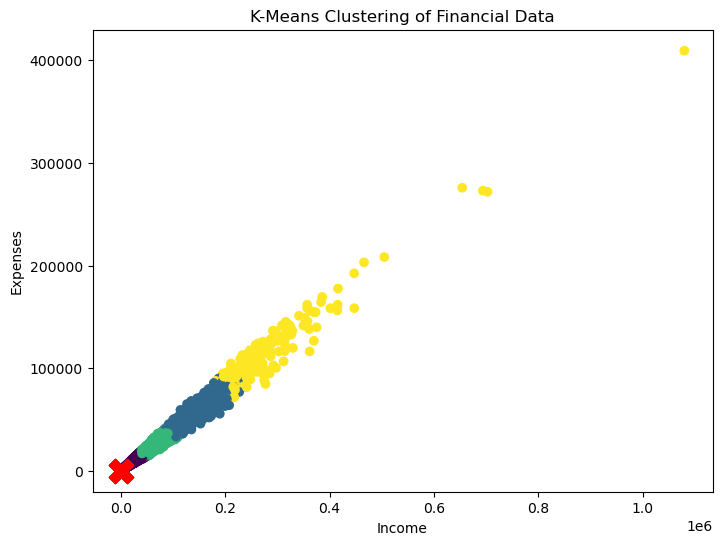

In [28]:
# ✅ Create folder BEFORE saving the figure
os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(8,6))

# Plot data points
plt.scatter(df['Income'], df['expenses'], c=kmeans.labels_, cmap='viridis')

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X'
)

# Labels
plt.xlabel('Income')
plt.ylabel('Expenses')
plt.title('K-Means Clustering of Financial Data')

# Save image
plt.savefig(
    "outputs/figures/k_means_clustering_of_financial_data.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Elbow method

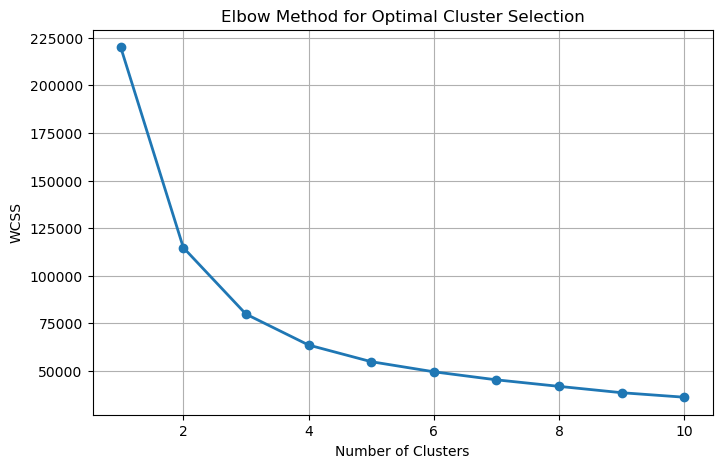

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for cluster range 1 to 10
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linewidth=2)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Cluster Selection")
plt.grid(True)
plt.show()

cluster visualization graph

In [30]:
# Create total savings column from multiple savings-related columns
savings_cols = [
    "Potential_Savings_Utilities",
    "Potential_Savings_Education",
    "Potential_Savings_Healthcare",
    "Potential_Savings_Groceries",
    "Potential_Savings_Transport",
    "Potential_Savings_Miscellaneous"
]

df["Total_Savings"] = df[savings_cols].sum(axis=1)

print("Total_Savings column created successfully")
df[["Income", "Total_Savings"]].head()

Total_Savings column created successfully


,Income,Total_Savings
0,44637.249636,2846.302349
1,26858.596592,1106.620799
2,50367.605084,2680.494070
3,101455.600247,4517.312528
4,24875.283548,1262.470807


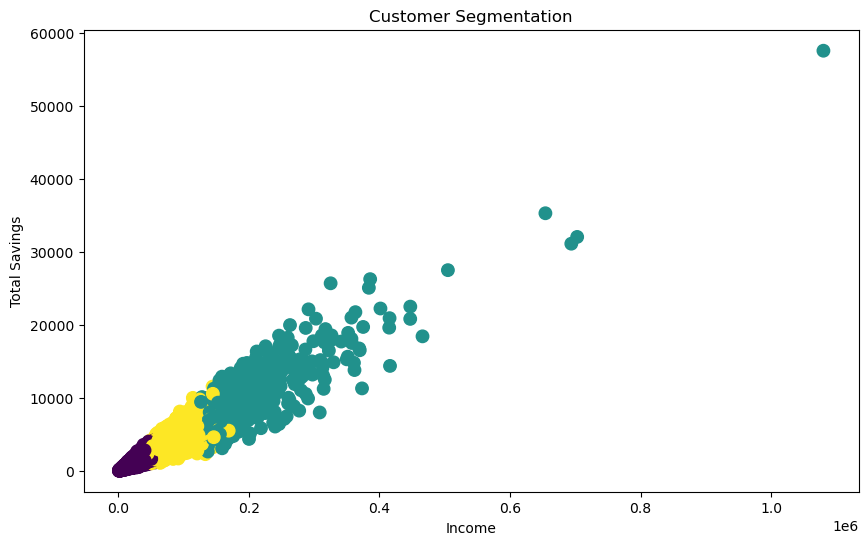

In [31]:
# Step 1: Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Step 2: Graph
plt.figure(figsize=(10,6))
plt.scatter(df["Income"], df["Total_Savings"], c=df["cluster"], s=80)
plt.xlabel("Income")
plt.ylabel("Total Savings")
plt.title("Customer Segmentation")
plt.show()

In [32]:
# Cluster-wise summary insights
cluster_summary = df.groupby("cluster")[["Income", "Total_Savings"]].mean().round(2)

print("Cluster-wise Financial Summary:")
cluster_summary

Cluster-wise Financial Summary:


,Income,Total_Savings
cluster,,
0,24710.30,1228.62
1,195520.83,9798.63
2,76795.16,3820.41


In [33]:
# Save final clustered dataset
df.to_csv("outputs/final_clustered_finance_users.csv", index=False)

print("Final clustered dataset saved successfully")

Final clustered dataset saved successfully
